# 02 · Arquitectura del ciclo, crédito y temperatura de riesgo

Este notebook implementa una mesa de análisis manual alrededor de cuatro preguntas separadas:

$$Macro\rightarrow CycleLocation,\quad Fundamental\rightarrow AssetQuality/Valuation$$
$$Technical\rightarrow Timing,\quad Psychology/Credit\rightarrow RiskTemperature$$

Luego combina —sin confundir— estados determinísticos, ciclos menores dentro de un megaciclo, un `CycleTopScore` experimental, una vista probabilística opcional y un mapeo gradual `Aggressive ↔ Defensive`. Es una formalización cuantitativa independiente inspirada en ideas públicas de Maru Cape y Howard Marks; no es una reproducción propietaria ni asesoramiento financiero.

## Fuente y modo de ejecución / Source and execution mode

`DATA_MODE='synthetic'` usa una demostración determinística. Los modos `auto` y `cycle1` se rechazan antes de leer archivos históricos; el adaptador real requiere una futura configuración explícita de fuentes y particiones.

Los ejemplos iniciales ilustran cálculos sobre series sintéticas. El Workbench al final usa otros escenarios con scores ingresados a mano y los identifica por separado. Ninguno representa una evaluación actual del mercado.


In [1]:
from dataclasses import asdict
from datetime import date
from pathlib import Path
from collections import Counter
import hashlib
import json
import math
import warnings
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

from spy_predictor_quant.cycle_analysis_tools import (
    STATE_LABELS, CreditInputs, CycleStateObservation, ExposurePolicy,
    ExploratoryStateThresholds, LatentStateSpec, LevelObservation,
    NestedCycleConfig, NestedCycleObservation, SignedComponent, TopScoreConfig,
    calculate_credit_amplifier, calculate_cycle_architecture, calculate_cycle_top_score,
    classify_exploratory_states, compute_trailing_structural_trend,
    diagnose_nested_cycles, filter_latent_states, map_state_probabilities_to_exposure,
)

DATA_MODE = 'synthetic'  # Secondary workbench currently supports synthetic inputs only.
if DATA_MODE != 'synthetic':
    raise ValueError('Real-data notebook access is closed pending the secondary manifest adapter.')
INSTRUMENT = 'SPY'       # SPY or QQQ
SYNTHETIC_SEED = 20260906
RUN_OPTIONAL_LATENT_FILTER = False  # Must stay False for frozen Cycle 1 run

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'config' / 'cycle1.json').exists(): return candidate
    raise FileNotFoundError('Repository root not found')
REPO_ROOT = find_repo_root()

def month_dates(count, start_year=2000, start_month=1):
    result = []
    for offset in range(count):
        ordinal = start_year*12 + start_month-1 + offset
        result.append(date(ordinal//12, ordinal%12+1, 1))
    return result

def read_ndjson(path):
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

def verify(path, expected):
    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    if actual != expected: raise ValueError(f'Hash mismatch for {path}')

def synthetic_inputs():
    rng = np.random.default_rng(SYNTHETIC_SEED); n = 288; t = np.arange(n, dtype=float)
    macro = np.clip(0.75*np.sin(2*np.pi*(t-8)/94) + rng.normal(0,.07,n), -1, 1)
    risk_wave = np.sin(2*np.pi*(t-28)/82)
    credit_ease_driver = np.clip(0.72*risk_wave + .18*np.sin(2*np.pi*t/31), -1, 1)
    fundamentals = np.clip(.55*macro + .25*np.sin(2*np.pi*t/143), -1, 1)
    log_price = 4.5 + .0031*t + .17*risk_wave + .05*np.sin(2*np.pi*t/23)
    log_price -= .34*np.exp(-.5*((t-106)/7)**2) + .28*np.exp(-.5*((t-226)/6)**2)
    log_price += rng.normal(0,.012,n); price = np.exp(log_price)
    mom6 = np.zeros(n); mom6[6:] = np.clip((log_price[6:]-log_price[:-6])/0.16, -1, 1)
    spread = np.clip(-credit_ease_driver + .30*np.exp(-.5*((t-106)/8)**2), -1, 1)
    spread_change = np.clip(np.r_[0, np.diff(spread)]*4, -1, 1)
    defaults = np.clip(.7*np.roll(spread, 5) - .2, -1, 1); defaults[:5] = defaults[5]
    return {'dates': month_dates(n), 'price': price, 'macro': macro,
            'valuation': np.clip(-risk_wave, -1, 1), 'direction': mom6,
            'fundamental': fundamentals, 'spread': spread, 'spread_change': spread_change,
            'standards': np.clip(.8*spread, -1, 1),
            'leverage': np.clip(.85*credit_ease_driver, -1, 1),
            'underwriting': np.clip(.9*credit_ease_driver, -1, 1), 'defaults': defaults,
            'meta': {'source':'deterministic-synthetic','seed':SYNTHETIC_SEED,
                     'evidenceTier':'DEMONSTRATION_ONLY','manifest':None,
                     'proxyMap':'All drivers are synthetic and known.'}}

def newest_manifest(instrument):
    candidates=[]
    for path in REPO_ROOT.glob(f'datasets/cycle1/cycle1-monthly-*/validation-{instrument.lower()}/manifest.json'):
        root_path=path.parents[1]/'manifest.json'
        if root_path.exists():
            root=json.loads(root_path.read_text(encoding='utf-8')); candidates.append((root.get('asOfDate',''),path.as_posix(),path))
    return max(candidates)[2] if candidates else None

def cycle1_inputs(instrument):
    path=newest_manifest(instrument)
    if path is None: raise FileNotFoundError(f'No Cycle 1 manifest for {instrument}')
    root=json.loads((path.parents[1]/'manifest.json').read_text(encoding='utf-8'))
    track_entry=next(item for item in root['tracks'] if item['instrument']==instrument)
    verify(path,track_entry['manifestSha256'])
    manifest=json.loads(path.read_text(encoding='utf-8'))
    arts={x['kind']:x for x in manifest['normalizedArtifacts']}
    for item in arts.values(): verify(REPO_ROOT/item['path'], item['sha256'])
    features=read_ndjson(REPO_ROOT/arts['features-and-states']['path'])
    daily=read_ndjson(REPO_ROOT/arts['total-return-index']['path']); month_end={}
    for row in daily:
        key=row['sessionDate'][:7]
        if key not in month_end or row['sessionDate']>month_end[key]['sessionDate']: month_end[key]=row
    aligned=[]
    for row in features:
        key=row['snapshotDate'][:7]
        if key in month_end: aligned.append((row,month_end[key]))
    raw=[x[0]['normalizedFeatures'] for x in aligned]; dims=[x[0]['dimensionScores'] for x in aligned]
    return {'dates':[date.fromisoformat(x[0]['snapshotDate']) for x in aligned],
            'price':np.asarray([float(x[1]['totalReturnIndex']) for x in aligned]),
            'macro':np.asarray([r['industrial-production-growth-6m'] for r in raw]),
            'valuation':np.asarray([d['valuation'] for d in dims]),
            'direction':np.asarray([d['direction'] for d in dims]),
            'fundamental':np.asarray([d['valuation'] for d in dims]),
            'spread':np.asarray([r['national-financial-conditions-index'] for r in raw]),
            'spread_change':-np.asarray([r['financial-conditions-change-3m'] for r in raw]),
            'standards':np.asarray([d['stress'] for d in dims]),
            'leverage':-np.asarray([d['stress'] for d in dims]),
            'underwriting':-np.asarray([d['stress'] for d in dims]),
            'defaults':np.asarray([r['drawdown-from-trailing-high-12m'] for r in raw]),
            'meta':{'source':'cycle1-verified-artifacts','seed':None,'evidenceTier':manifest['evidenceTier'],
                    'manifest':str(path.relative_to(REPO_ROOT)),
                    'proxyMap':'Macro=INDPRO score; leverage/underwriting=-stress proxies; defaults=drawdown proxy.'}}

def load_inputs():
    if DATA_MODE not in {'auto','cycle1','synthetic'}: raise ValueError(DATA_MODE)
    if DATA_MODE!='synthetic':
        try: return cycle1_inputs(INSTRUMENT)
        except FileNotFoundError:
            if DATA_MODE=='cycle1': raise
            warnings.warn('Cycle 1 manifest absent; using deterministic synthetic data')
    return synthetic_inputs()

data=load_inputs(); labels=np.asarray([d.isoformat()[:7] for d in data['dates']])
print(json.dumps(data['meta'],indent=2,ensure_ascii=False))
print({'rows':len(labels),'firstMonth':labels[0],'lastMonth':labels[-1],
       'optionalLatentFilterEnabled':RUN_OPTIONAL_LATENT_FILTER,'matplotlib':HAS_MATPLOTLIB})


{
  "source": "deterministic-synthetic",
  "seed": 20260906,
  "evidenceTier": "DEMONSTRATION_ONLY",
  "manifest": null,
  "proxyMap": "All drivers are synthetic and known."
}
{'rows': 288, 'firstMonth': np.str_('2000-01'), 'lastMonth': np.str_('2023-12'), 'optionalLatentFilterEnabled': False, 'matplotlib': True}


/var/folders/w5/myt2hhln3_93z065wjfc7h5h0000gn/T/ipykernel_15681/2829497763.py:124: UserWarning: Cycle 1 manifest absent; using deterministic synthetic data
  warnings.warn('Cycle 1 manifest absent; using deterministic synthetic data')


## Herramienta 1 — Arquitectura de cuatro dimensiones

Cada componente llega normalizado y con signo económico explícito. Para una dimensión $D$:

$$D_t=\frac{\sum_i w_i s_i z_{i,t}}{\sum_i w_i},\qquad w_i>0,\;s_i\in\{-1,+1\}$$

Los pesos nunca codifican dirección; así evitamos dobles negaciones. `Macro` pregunta si la actividad mejora, `Fundamental` si calidad/valuación es atractiva, `Technical` si el precio confirma, y `Psychology/Credit` si la tolerancia al riesgo está caliente. Mantener cuatro scores evita que buen momentum esconda mala valuación o que una crisis de crédito se diluya en un promedio total. En el ejemplo los pesos son unitarios y explícitos; una versión productiva debe congelarlos antes de evaluación.

{'macro_cycle_location': {'name': 'macro_cycle_location', 'score': -0.036007057471396764, 'score_meaning': 'higher=favorable_or_improving_macro_evidence', 'contributions': {'growth': -0.036007057471396764}, 'total_weight': 1.0, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}, 'fundamental_asset_quality_valuation': {'name': 'fundamental_asset_quality_valuation', 'score': -0.4240941260696199, 'score_meaning': 'higher=stronger_quality_or_more_attractive_valuation', 'contributions': {'quality': -0.008822826007290943, 'valuation_attractiveness': -0.8393654261319489}, 'total_weight': 2.0, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}, 'technical_timing': {'name': 'technical_timing', 'score': 0.18524331947951667, 'score_meaning': 'higher=stronger_positive_direction_confirmation', 'contributions': {'direction': 0.18524331947951667}, 'total_weight': 1.0, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_

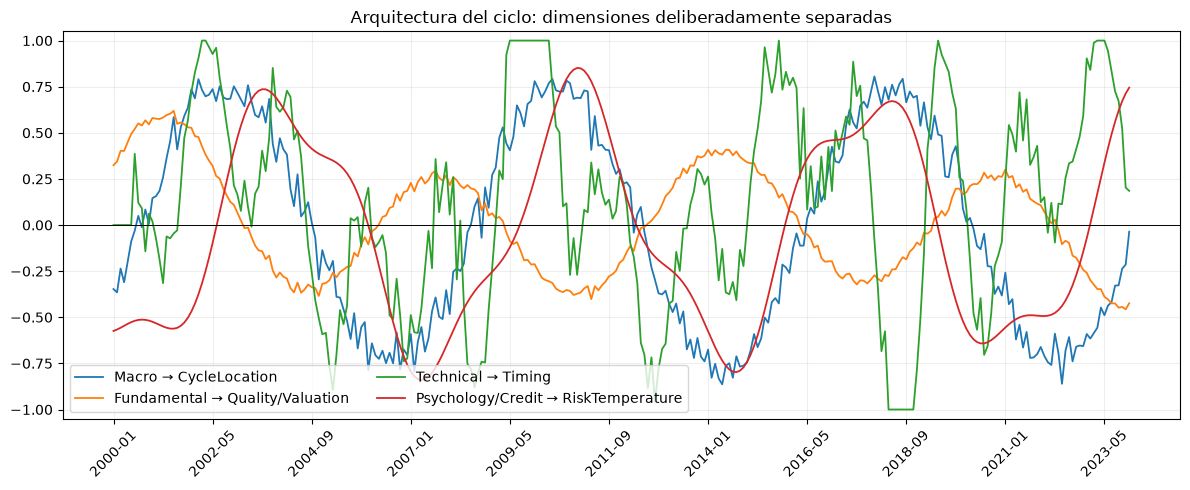

In [2]:
architectures=[]
for i in range(len(labels)):
    architectures.append(calculate_cycle_architecture(
        macro=(SignedComponent('growth',data['macro'][i],1),),
        fundamental=(SignedComponent('quality',data['fundamental'][i],1),
                     SignedComponent('valuation_attractiveness',data['valuation'][i],1)),
        technical=(SignedComponent('direction',data['direction'][i],1),),
        psychology_credit=(SignedComponent('spread',data['spread'][i],-1),
                           SignedComponent('underwriting_ease',data['underwriting'][i],1)),
    ))
macro_score=np.asarray([x.macro_cycle_location.score for x in architectures])
fundamental_score=np.asarray([x.fundamental_asset_quality_valuation.score for x in architectures])
technical_score=np.asarray([x.technical_timing.score for x in architectures])
psychology_score=np.asarray([x.psychology_credit_risk_temperature.score for x in architectures])
print(asdict(architectures[-1]))
if HAS_MATPLOTLIB:
    fig,ax=plt.subplots(figsize=(12,5))
    for values,name in ((macro_score,'Macro → CycleLocation'),(fundamental_score,'Fundamental → Quality/Valuation'),
                        (technical_score,'Technical → Timing'),(psychology_score,'Psychology/Credit → RiskTemperature')):
        ax.plot(labels,values,label=name,lw=1.3)
    ax.axhline(0,color='black',lw=.7); ax.set_ylim(-1.05,1.05); ax.legend(ncol=2); ax.grid(alpha=.2)
    ax.set_title('Arquitectura del ciclo: dimensiones deliberadamente separadas')
    step=max(1,len(labels)//10); ax.set_xticks(labels[::step]); ax.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


## Herramienta 2 — Crédito como amplificador

El circuito de Marks puede representarse como dos feedbacks:

$$Success\rightarrow Confidence\rightarrow RiskTaking\rightarrow Fragility\rightarrow Failure$$
$$Failure\rightarrow Fear\rightarrow RiskAvoidance\rightarrow BetterPricing\rightarrow FutureSuccess$$

La herramienta separa `current_stress` de `latent_fragility`. Spreads bajos, estándares laxos, leverage y underwriting fáciles elevan tolerancia y fragilidad aun cuando defaults contemporáneos sean bajos. Todos los inputs deben ser z-scores históricos trailing y punto-en-tiempo; nombres y direcciones están fijados en `CreditInputs`. En el camino Cycle 1 algunos campos son sólo proxies derivados, declarados en `proxyMap`, por lo que no deben presentarse como mediciones directas de lending standards o leverage.

{'credit_ease': 0.5152364634099644, 'risk_tolerance': 0.6291442000317006, 'current_stress': -0.5269124475205054, 'latent_fragility': 0.6123432499868076, 'risk_temperature': 0.5894666325130045, 'semantics': {'credit_ease': 'higher=easier_credit', 'risk_tolerance': 'higher=greater_risk_tolerance', 'current_stress': 'higher=greater_current_credit_stress', 'latent_fragility': 'higher=more_boom_created_fragility', 'risk_temperature': 'higher=hotter_credit_risk_taking_environment'}, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}


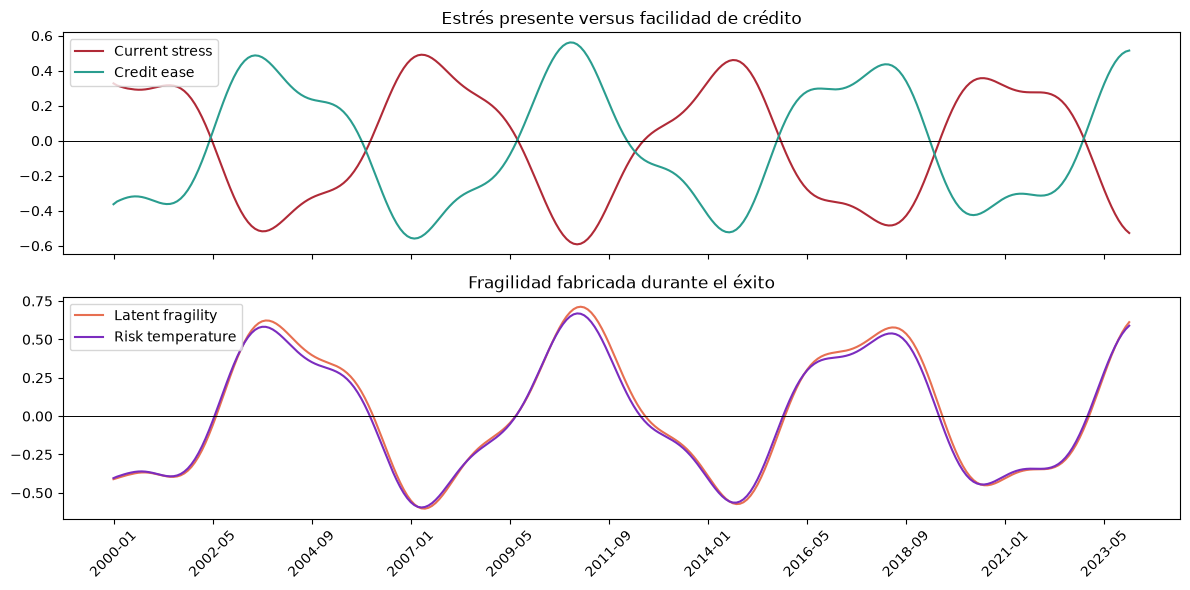

In [3]:
credit=[]
for i in range(len(labels)):
    credit.append(calculate_credit_amplifier(CreditInputs(
        spread_level=data['spread'][i], spread_change=data['spread_change'][i],
        lending_standards_tightness=data['standards'][i], leverage_growth=data['leverage'][i],
        underwriting_ease=data['underwriting'][i], default_rate=data['defaults'][i])))
credit_ease=np.asarray([x.credit_ease for x in credit]); current_stress=np.asarray([x.current_stress for x in credit])
latent_fragility=np.asarray([x.latent_fragility for x in credit]); risk_temperature=np.asarray([x.risk_temperature for x in credit])
print(asdict(credit[-1]))
if HAS_MATPLOTLIB:
    fig,axes=plt.subplots(2,1,figsize=(12,6),sharex=True)
    axes[0].plot(labels,current_stress,label='Current stress',color='#b02a37'); axes[0].plot(labels,credit_ease,label='Credit ease',color='#2a9d8f')
    axes[0].axhline(0,color='black',lw=.7); axes[0].legend(); axes[0].set_title('Estrés presente versus facilidad de crédito')
    axes[1].plot(labels,latent_fragility,label='Latent fragility',color='#e76f51'); axes[1].plot(labels,risk_temperature,label='Risk temperature',color='#7b2cbf')
    axes[1].axhline(0,color='black',lw=.7); axes[1].legend(); axes[1].set_title('Fragilidad fabricada durante el éxito')
    step=max(1,len(labels)//10); axes[1].set_xticks(labels[::step]); axes[1].tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


## Herramienta 3 — Estados determinísticos auditables

Usamos seis estados: `CRISIS`, `EARLY_RECOVERY` (recuperación temprana/razonable), `NORMAL`, `GREED` (codicia), `EUPHORIA` y `CORRECTION`. Inputs: valuación atractiva positiva, stress positivo y dirección positiva. Las reglas y precedencia son transparentes: EUPHORIA → EARLY_RECOVERY → CRISIS → CORRECTION → GREED → NORMAL.

Ejemplos: crisis combina barato+stress alto+dirección débil; euforia combina caro+stress fácil+dirección positiva; recovery exige barato+stress que declina+dirección positiva. Un estado es una descripción condicional, no una predicción ni una orden. Los defaults coinciden con Cycle 1, pero al alimentar dimensiones exploratorias el resultado también es exploratorio.

{'stateCounts': {np.str_('NORMAL'): 211, np.str_('EUPHORIA'): 6, np.str_('GREED'): 36, np.str_('CORRECTION'): 35}, 'latest': {'as_of': datetime.date(2023, 12, 1), 'state': 'NORMAL', 'flags': {'cheap': False, 'expensive': True, 'highStress': False, 'easyStress': True, 'positiveDirection': False, 'weakDirection': False, 'stressRising': False, 'stressDeclining': False, 'formerlyExpensive': True}, 'stress_change': -0.07292907461170284, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}}


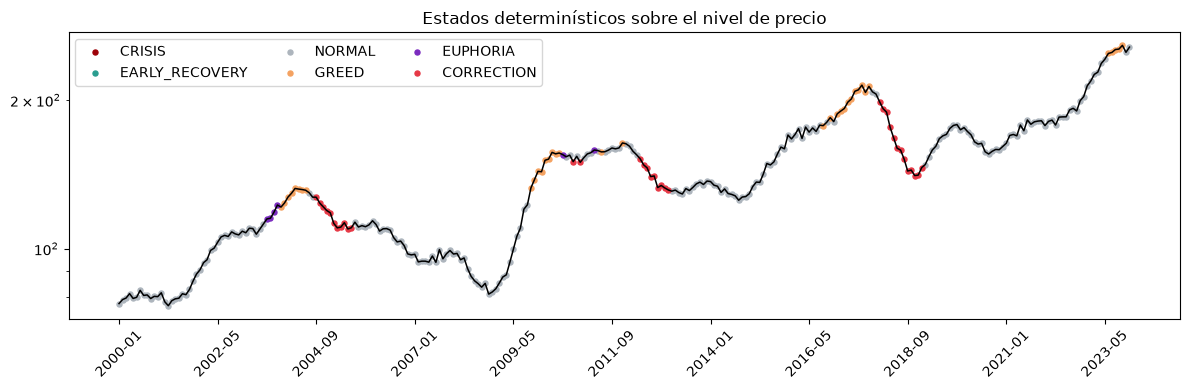

In [4]:
state_inputs=[CycleStateObservation(d,float(v),float(s),float(m))
              for d,v,s,m in zip(data['dates'],data['valuation'],current_stress,technical_score)]
deterministic_states=classify_exploratory_states(state_inputs,thresholds=ExploratoryStateThresholds())
state_labels=np.asarray([x.state for x in deterministic_states])
print({'stateCounts':dict(Counter(state_labels)),'latest':asdict(deterministic_states[-1])})
if HAS_MATPLOTLIB:
    colors={'CRISIS':'#9d0208','EARLY_RECOVERY':'#2a9d8f','NORMAL':'#adb5bd','GREED':'#f4a261','EUPHORIA':'#7b2cbf','CORRECTION':'#e63946'}
    fig,ax=plt.subplots(figsize=(12,4)); ax.plot(labels,data['price'],color='black',lw=1.1)
    for state in STATE_LABELS:
        mask=state_labels==state; ax.scatter(labels[mask],data['price'][mask],s=13,color=colors[state],label=state)
    ax.set_yscale('log'); ax.set_title('Estados determinísticos sobre el nivel de precio'); ax.legend(ncol=3)
    step=max(1,len(labels)//10); ax.set_xticks(labels[::step]); ax.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


## Herramienta 4 — Megaciclo y ciclos menores

La estructura conceptual es `Megacycle → Minor cycle 1...N → rally/correction/recovery`. El diagnóstico usa desviación estructural robusta para la zona del megaciclo, drawdown desde el máximo conocido y dirección para la fase menor. Una transición `CORRECTION → RECOVERY` abre un nuevo número de ciclo menor.

$$Drawdown_t=1-P_t/\max_{u\le t}P_u$$

La estimación estructural es Theil–Sen trailing-only de 60/84/120 meses. Una corrección dentro de una zona cara **no demuestra** el fin del megaciclo; `late_cycle_major_reversal_risk` sólo marca coincidencia descriptiva de zona sobrevaluada y corrección.

{'eligibleRows': 146, 'latest': {'as_of': datetime.date(2023, 12, 1), 'megacycle_zone': 'NORMAL', 'minor_phase': 'NEUTRAL', 'minor_cycle_number': 3, 'drawdown_from_running_high': 0.008123912723756344, 'late_cycle_major_reversal_risk': False, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}, 'majorReversalRiskFlags': 0}


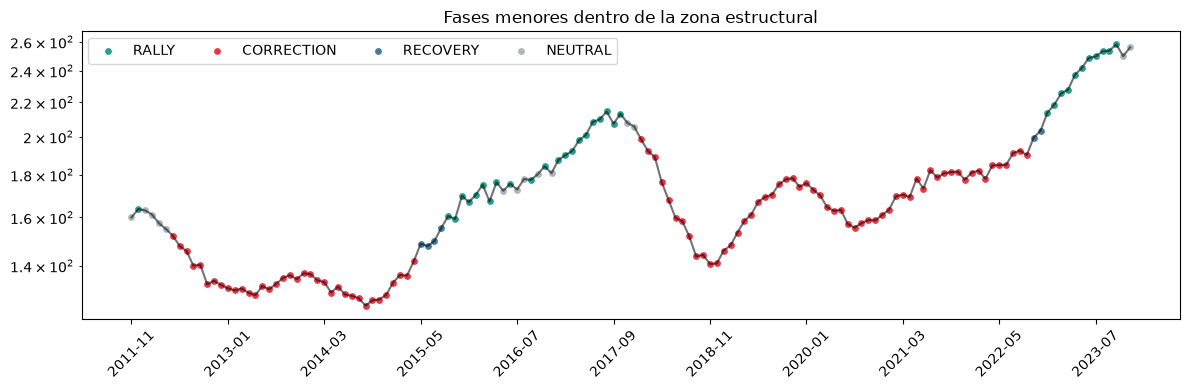

In [5]:
trend=compute_trailing_structural_trend(
    [LevelObservation(d,float(p)) for d,p in zip(data['dates'],data['price'])],
    windows=(60,84,120),scale_window=120,minimum_scale_history=24)
eligible=[i for i,x in enumerate(trend) if x.robust_deviation is not None]
nested_start=eligible[0] if eligible else len(trend)
nested=diagnose_nested_cycles([NestedCycleObservation(data['dates'][i],float(data['price'][i]),
                                float(trend[i].robust_deviation),float(technical_score[i]))
                               for i in range(nested_start,len(trend))],config=NestedCycleConfig())
print({'eligibleRows':len(nested),'latest':asdict(nested[-1]) if nested else None,
       'majorReversalRiskFlags':sum(x.late_cycle_major_reversal_risk for x in nested)})
if HAS_MATPLOTLIB and nested:
    phase_colors={'RALLY':'#2a9d8f','CORRECTION':'#e63946','RECOVERY':'#457b9d','NEUTRAL':'#adb5bd'}
    fig,ax=plt.subplots(figsize=(12,4)); nl=labels[nested_start:]; np_=data['price'][nested_start:]
    ax.plot(nl,np_,color='black',alpha=.55)
    phases=np.asarray([x.minor_phase for x in nested])
    for phase,color in phase_colors.items():
        mask=phases==phase; ax.scatter(nl[mask],np_[mask],s=15,color=color,label=phase)
    ax.set_yscale('log'); ax.set_title('Fases menores dentro de la zona estructural'); ax.legend(ncol=4)
    step=max(1,len(nl)//10); ax.set_xticks(nl[::step]); ax.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


## Herramienta 5 — `CycleTopScore` experimental

Una forma auditable del score es:

$$TopScore_t=\frac{\sum_i w_i s_i z_{i,t}}{\sum_iw_i}$$

Incluimos desviación de precio (+), stress (−), crecimiento (+), valuación cara (+), temperatura psicológica (+) y facilidad crediticia (+). `TopScore ≫ 0` significa más ingredientes típicos de final de ciclo; `TopScore ≪ 0`, crisis/pesimismo/subvaluación. No es regla binaria, probabilidad calibrada ni candidato Cycle 1. Los pesos/signos explícitos de esta demostración deben preregistrarse en una versión nueva antes de evaluar performance. Para Argentina, country risk y REER requerirían fuentes calificadas propias; no se sustituyen silenciosamente con proxies de EE.UU.

{'latestScore': 0.5632313090329327, 'latestContributions': {'score': 0.5632313090329327, 'contributions': {'price_deviation': 0.9444139420935703, 'stress': 0.5269124475205054, 'growth': -0.036007057471396764, 'expensive_valuation': 0.8393654261319489, 'sentiment': 0.5894666325130045, 'credit_ease': 0.5152364634099644}, 'configured_signs': {'price_deviation': 1, 'stress': -1, 'growth': 1, 'expensive_valuation': 1, 'sentiment': 1, 'credit_ease': 1}, 'total_weight': 6.0, 'interpretation': 'higher=more_late_cycle_or_top_like_evidence', 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}}


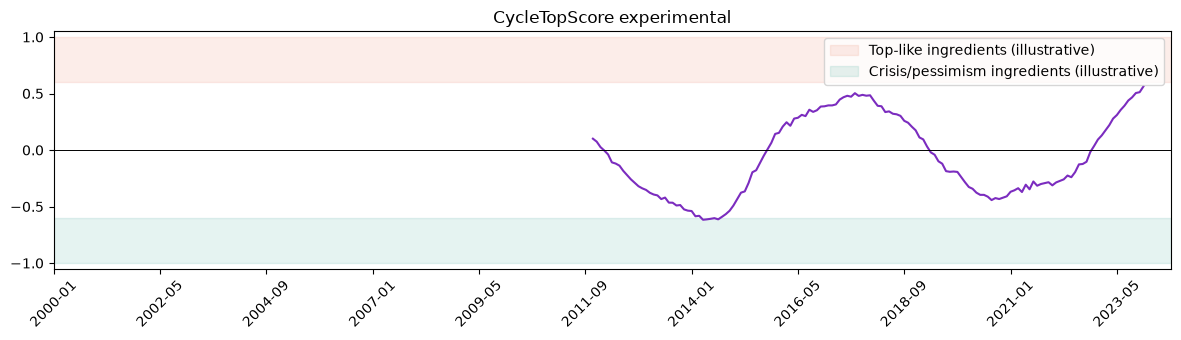

In [6]:
top_config=TopScoreConfig(
    weights={'price_deviation':1.0,'stress':1.0,'growth':1.0,'expensive_valuation':1.0,'sentiment':1.0,'credit_ease':1.0},
    signs={'price_deviation':1,'stress':-1,'growth':1,'expensive_valuation':1,'sentiment':1,'credit_ease':1})
top_score=np.full(len(labels),np.nan); top_details=[]
for i in eligible:
    result=calculate_cycle_top_score({
        'price_deviation':float(np.clip(trend[i].robust_deviation,-1,1)), 'stress':float(current_stress[i]),
        'growth':float(macro_score[i]), 'expensive_valuation':float(-data['valuation'][i]),
        'sentiment':float(risk_temperature[i]), 'credit_ease':float(credit_ease[i])},top_config)
    top_score[i]=result.score; top_details.append(result)
print({'latestScore':float(top_score[np.isfinite(top_score)][-1]) if np.isfinite(top_score).any() else None,
       'latestContributions':asdict(top_details[-1]) if top_details else None})
if HAS_MATPLOTLIB:
    fig,ax=plt.subplots(figsize=(12,3.5)); ax.plot(labels,top_score,color='#7b2cbf')
    ax.axhline(0,color='black',lw=.7); ax.axhspan(.6,1,color='#e76f51',alpha=.12,label='Top-like ingredients (illustrative)')
    ax.axhspan(-1,-.6,color='#2a9d8f',alpha=.12,label='Crisis/pessimism ingredients (illustrative)')
    ax.set_ylim(-1.05,1.05); ax.set_title('CycleTopScore experimental'); ax.legend()
    step=max(1,len(labels)//10); ax.set_xticks(labels[::step]); ax.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


## Herramienta 6 — Estado latente probabilístico (opcional; fuera de Cycle 1)

Podemos formalizar $Z_t\in\{Crisis,EarlyRecovery,Normal,Greed,Euphoria,Correction\}$ y filtrar:

$$P(Z_t=k\mid X_{1:t})$$

La herramienta hace filtrado forward-only con emisiones Gaussianas diagonales y transición **fijas**; no ajusta parámetros ni usa smoothing futuro. Los centros, escalas y matriz de abajo son ilustrativos, no calibrados. `RUN_OPTIONAL_LATENT_FILTER=False` por defecto porque la preregistración congela `hmmIncluded=false`, cero evaluaciones HMM y exactamente 5 modelos × 2 instrumentos = 10 evaluaciones. Activarlo sólo crea un diagnóstico de notebook y jamás debe mezclarse con el primer run congelado.

In [7]:
latent=None
if RUN_OPTIONAL_LATENT_FILTER:
    feature_names=('valuation','stress','direction','risk_temperature')
    means={
      'CRISIS':(.8,.9,-.7,-.7),'EARLY_RECOVERY':(.7,.5,.6,-.3),'NORMAL':(0,0,0,0),
      'GREED':(-.7,-.3,.5,.7),'EUPHORIA':(-.9,-.7,.7,.9),'CORRECTION':(-.4,.5,-.7,.2)}
    latent_specs=tuple(LatentStateSpec(name,means[name],(.55,.55,.55,.55)) for name in STATE_LABELS)
    transition=tuple(tuple(.85 if i==j else .03 for j in range(6)) for i in range(6))
    latent=filter_latent_states([{'valuation':float(v),'stress':float(s),'direction':float(d),'risk_temperature':float(r)}
                                 for v,s,d,r in zip(data['valuation'],current_stress,technical_score,risk_temperature)],
                                feature_names=feature_names,states=latent_specs,transition_matrix=transition)
    print({'latestLatentState':asdict(latent[-1]),'cycle1EvaluationsAdded':0})
else:
    print('SKIPPED_BY_DESIGN: HMM/latent filter is not included in frozen Cycle 1.')


SKIPPED_BY_DESIGN: HMM/latent filter is not included in frozen Cycle 1.


## Herramienta 7 — Política gradual `Aggressive ↔ Defensive`

En vez de `if BOTTOM: buy_everything`, la herramienta calcula:

$$RiskBudget_t=\sum_k P(Z_t=k)Budget_k$$

con fallback por baja confianza y límite de cambio mensual. Aquí usamos probabilidades latentes sólo si se habilitó la celda opcional; de lo contrario usamos el estado determinístico como distribución one-hot. Los presupuestos son ejemplos educativos: crisis/recovery reciben mayor capacidad de riesgo y greed/euphoria menor. `maximum_change=0.10` limita saltos, pero no incorpora objetivos, restricciones, impuestos, liquidez ni tolerancia personal. **No ejecutar como cartera real.**

{'probabilitySource': 'deterministic one-hot', 'latest': {'risk_budget': 0.5, 'posture': 'NEUTRAL', 'most_likely_state': 'NORMAL', 'confidence': 1.0, 'used_fallback': False, 'unconstrained_budget': 0.5, 'notice': 'EXPLORATORY_DIAGNOSTIC_NOT_PART_OF_FROZEN_CYCLE1_AND_NOT_INVESTMENT_ADVICE'}, 'warning': 'Research mapping only; not investment advice'}


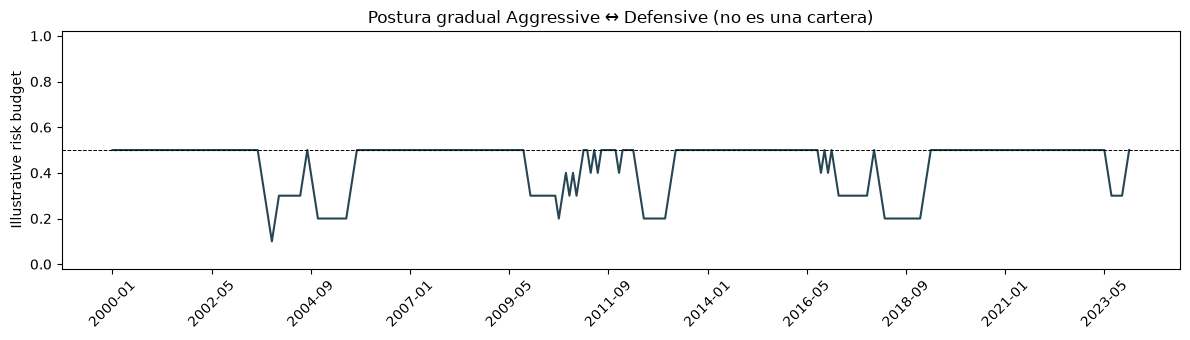

In [8]:
budgets={'CRISIS':.90,'EARLY_RECOVERY':.80,'NORMAL':.50,'GREED':.30,'EUPHORIA':.10,'CORRECTION':.20}
policy=ExposurePolicy(budgets,fallback_budget=.50,minimum_confidence=.60,maximum_change=.10)
probability_rows=[x.probabilities for x in latent] if latent is not None else [
    {name:(1.0 if name==state else 0.0) for name in STATE_LABELS} for state in state_labels]
mappings=[]; previous=.50
for probabilities in probability_rows:
    mapped=map_state_probabilities_to_exposure(probabilities,policy,previous_budget=previous)
    mappings.append(mapped); previous=mapped.risk_budget
risk_budget=np.asarray([x.risk_budget for x in mappings])
print({'probabilitySource':'optional fixed HMM' if latent is not None else 'deterministic one-hot',
       'latest':asdict(mappings[-1]),'warning':'Research mapping only; not investment advice'})
if HAS_MATPLOTLIB:
    fig,ax=plt.subplots(figsize=(12,3.5)); ax.plot(labels,risk_budget,color='#264653',lw=1.5)
    ax.axhline(.5,color='black',lw=.7,ls='--'); ax.set_ylim(-.02,1.02); ax.set_ylabel('Illustrative risk budget')
    ax.set_title('Postura gradual Aggressive ↔ Defensive (no es una cartera)')
    step=max(1,len(labels)//10); ax.set_xticks(labels[::step]); ax.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


## Checklist de interpretación y próximos pasos

1. Verificar `source`, `evidenceTier`, `manifest` y `proxyMap`; un proxy no se convierte en dato observado por aparecer en un gráfico.
2. Leer las cuatro dimensiones por separado antes de cualquier score compuesto.
3. Contrastar stress actual con fragilidad latente: pocos defaults pueden coincidir con underwriting deteriorándose.
4. Tratar los estados como vocabulario descriptivo con precedencia, no como verdad latente.
5. No interpretar cada corrección como final de megaciclo.
6. Mantener HMM, TopScore, nested cycles y política fuera de los diez candidatos Cycle 1. Cualquier evaluación requiere nueva preregistración.
7. Para Argentina, calificar fuentes point-in-time de EMBI/country risk, REER, GDP, valuación y crédito antes de reemplazar la demostración.

**No investment advice / No es asesoramiento financiero.**

## Workbench · Mediciones validadas y evaluación / Validated inputs and assessment

El panel puede cargar un manifiesto local con mediciones, unidades, instrumento, fuentes y fechas de disponibilidad. Verifica el esquema y SHA-256 del archivo antes de calcular los scores. Una revisión retirada queda faltante; no reaparece su valor anterior.

**El ejemplo incluido sigue siendo sintético.** Cambiar el ticker no descarga datos. Para analizar otras mediciones, seleccione su manifiesto y directorio explícitamente. La validación prueba integridad y coherencia de inputs, no autenticidad independiente de la fuente ni probabilidad de éxito. Las transformaciones y umbrales siguen siendo ilustrativos, no fórmulas propietarias verificadas.

Las series educativas anteriores permanecen sintéticas y separadas de este panel. No hay fallback automático cuando un manifiesto es inválido.


In [ ]:
from spy_predictor_quant.cycle_workbench import (
    SCENARIOS, COMPONENTS, assess, synthetic_fixture, render_html, export_report,
)
from spy_predictor_quant.cycle_workbench_inputs import load_workbench_inputs
from IPython.display import HTML, display

WORKBENCH_INPUT_MODE = 'manifest'  # 'manifest' or 'fixture'; never auto-fallback.
# Current verified macro snapshot; earlier educational charts stay synthetic.
WORKBENCH_INPUT_ROOT = REPO_ROOT / 'datasets' / 'workbench' / 'current-20260909'
WORKBENCH_MANIFEST = WORKBENCH_INPUT_ROOT / 'SPY-manifest.json'  # QQQ-manifest.json is also available.
WORKBENCH_AS_OF = json.loads((WORKBENCH_INPUT_ROOT / 'verification.json').read_text())['as_of']
WORKBENCH_SCENARIO = 'cheap-deteriorating'  # Used only in fixture mode.
WORKBENCH_SYMBOL = None  # Manifest identity by default; an override must match.
EXPORT_WORKBENCH = False
WORKBENCH_OUTPUT = REPO_ROOT / 'reports' / 'cycle-workbench' / 'notebooks'

input_audit = None
if WORKBENCH_INPUT_MODE == 'manifest':
    validated_inputs = load_workbench_inputs(WORKBENCH_MANIFEST,
        as_of=WORKBENCH_AS_OF, allowed_root=WORKBENCH_INPUT_ROOT)
    symbol = validated_inputs.metadata['symbol']
    if WORKBENCH_SYMBOL is not None and WORKBENCH_SYMBOL != symbol:
        raise ValueError('Symbol override does not match the manifest instrument.')
    workbench_report = assess(validated_inputs.observations, as_of=WORKBENCH_AS_OF,
        symbol=symbol, input_metadata=validated_inputs.metadata)
    input_audit = validated_inputs.audit
    print('Input validation:', validated_inputs.metadata['validation_scope'])
    print('Evidence tier:', validated_inputs.metadata['evidence_tier'])
    print('Input-file audit:', input_audit)
elif WORKBENCH_INPUT_MODE == 'fixture':
    workbench_report = assess(synthetic_fixture(WORKBENCH_SCENARIO),
        as_of=WORKBENCH_AS_OF, symbol=WORKBENCH_SYMBOL or 'DEMO')
else:
    raise ValueError('Choose manifest or fixture explicitly.')
display(HTML(render_html(workbench_report)))
if EXPORT_WORKBENCH:
    print(export_report(workbench_report, WORKBENCH_OUTPUT, input_audit=input_audit))


In [ ]:
# Selected input panel: derived scores, not the separate scenario comparison.
if HAS_MATPLOTLIB:
    selected = workbench_report['components']
    labels = list(COMPONENTS)
    values = [selected[key]['score'] if selected[key]['status'] == 'FRESH' else np.nan for key in labels]
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.bar(labels, np.nan_to_num(values), color=['#c45a50' if key == 'stress' else '#4c78a8' for key in labels])
    ax.axhline(0, color='gray', linewidth=.7)
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(f"{workbench_report['symbol']} · {workbench_report['instrument']['action']} · {', '.join(workbench_report['evidence_tiers'])}")
    for i, (key, value) in enumerate(zip(labels, values)):
        ax.text(i, 0 if np.isnan(value) else value, selected[key]['status'] if np.isnan(value) else f'{value:.2f}', ha='center', va='bottom')
    ax.set_ylabel('Illustrative score; stress higher = more risk')
    plt.tight_layout()
    plt.show()


### Comparar escenarios / Compare scenarios

El panel muestra cómo cambia el análisis al cambiar los componentes. Un activo aparentemente barato puede exigir esperar si el precio sigue deteriorándose. Calidad y valuación son inputs sintéticos explícitos: no se infieren de una caída de precio. La cobertura mide datos disponibles, no probabilidad de éxito.


In [ ]:
scenario_reports = [assess(synthetic_fixture(case), as_of=WORKBENCH_AS_OF,
                           symbol=f'DEMO:{case}') for case in SCENARIOS]
for case, report in zip(SCENARIOS, scenario_reports):
    print(f"{case:22s} market={report['market']['posture']:22s} instrument={report['instrument']['action']}")
if HAS_MATPLOTLIB:
    matrix = np.array([[report['components'][key]['score']
                        if report['components'][key]['status'] == 'FRESH' else np.nan
                        for key in COMPONENTS] for report in scenario_reports], dtype=float)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    heat = ax.imshow(np.ma.masked_invalid(matrix), cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(COMPONENTS)), COMPONENTS)
    ax.set_yticks(range(len(SCENARIOS)), SCENARIOS)
    ax.set_title('Handcrafted component scores · stress higher = more risk; others higher = supportive')
    for row in range(len(SCENARIOS)):
        for col in range(len(COMPONENTS)):
            value = matrix[row, col]
            ax.text(col, row, 'missing' if np.isnan(value) else f'{value:.1f}', ha='center', va='center')
    fig.colorbar(heat, ax=ax, label='Illustrative score (not probability)')
    plt.tight_layout()
    plt.show()
